<a href="https://colab.research.google.com/github/milicak/Data_Analysis_Course/blob/main/05_correleation_coefficient_hypothesis_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import kendalltau

In [2]:
x = np.linspace(-2,2,100)
err = np.zeros(x.shape[0])
import random
for i in range(x.shape[0]):
    err[i] = (random.uniform(-.5,0.5))

In [3]:
err

array([-0.3439312 ,  0.26282735, -0.23227344,  0.0428712 , -0.27191334,
       -0.30441777, -0.01008274, -0.16007162,  0.36424138,  0.30260296,
        0.1064322 ,  0.24206139,  0.11336038, -0.37589465,  0.4397455 ,
       -0.03665648,  0.13783044, -0.37445683, -0.10041404, -0.30249819,
        0.2907126 , -0.26509315,  0.33547904, -0.28873713,  0.25144407,
        0.19383714, -0.11066155, -0.43609743,  0.13823552, -0.12739991,
        0.20394484,  0.10483349,  0.12344896, -0.25226331, -0.44556258,
        0.06319755, -0.47158496,  0.38795667,  0.47632517,  0.41845522,
        0.3200899 ,  0.34487348,  0.07674972,  0.06128198, -0.30951627,
       -0.1998943 , -0.38961429,  0.06922952,  0.49646505,  0.08327523,
        0.14089583, -0.36564346,  0.17126758,  0.4839377 , -0.30775379,
        0.16484542,  0.3443273 , -0.19860419, -0.45745574, -0.03489445,
        0.27254495,  0.37501796,  0.0483258 , -0.12793056, -0.09698695,
        0.48043661,  0.02684447,  0.45055778, -0.15453495, -0.36

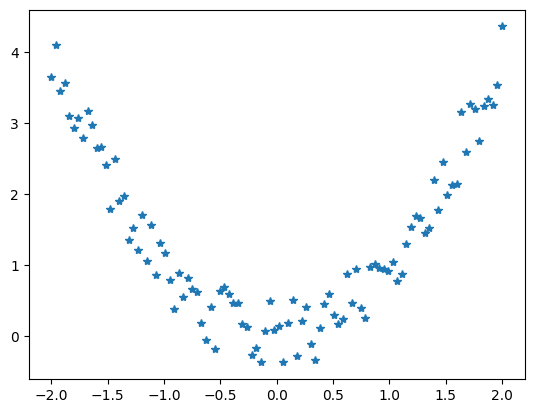

In [4]:
y = x**2+err
plt.plot(x,y,'*')

In [5]:
spearmanr(x,y)

SignificanceResult(statistic=np.float64(-0.0033603360336033603), pvalue=np.float64(0.9735302722161986))

In [6]:
kendalltau(x,y)

SignificanceResult(statistic=np.float64(-0.0012121212121212123), pvalue=np.float64(0.9857435982287576))

In [7]:
pearsonr(x,y)

PearsonRResult(statistic=np.float64(-0.014559617734032304), pvalue=np.float64(0.8856795051113081))

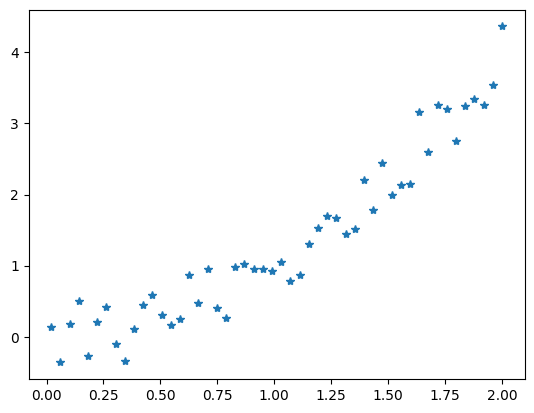

In [8]:
plt.plot(x[50:],y[50:],'*')

In [9]:
spearmanr(x[50:],y[50:])

SignificanceResult(statistic=np.float64(0.9529411764705881), pvalue=np.float64(1.581401659581816e-26))

In [10]:
pearsonr(x[50:],y[50:])

PearsonRResult(statistic=np.float64(0.941040127061741), pvalue=np.float64(3.093991430402424e-24))

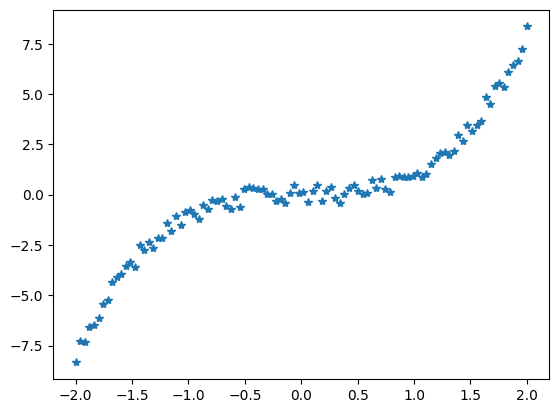

In [11]:
y = x**3+err
plt.plot(x,y,'*')

In [12]:
pearsonr(x,y),spearmanr(x,y),kendalltau(x,y)

(PearsonRResult(statistic=np.float64(0.9123551658966572), pvalue=np.float64(8.602683508180493e-40)),
 SignificanceResult(statistic=np.float64(0.963180318031803), pvalue=np.float64(1.0331057958063366e-57)),
 SignificanceResult(statistic=np.float64(0.8755555555555556), pvalue=np.float64(4.1016084521280565e-38)))

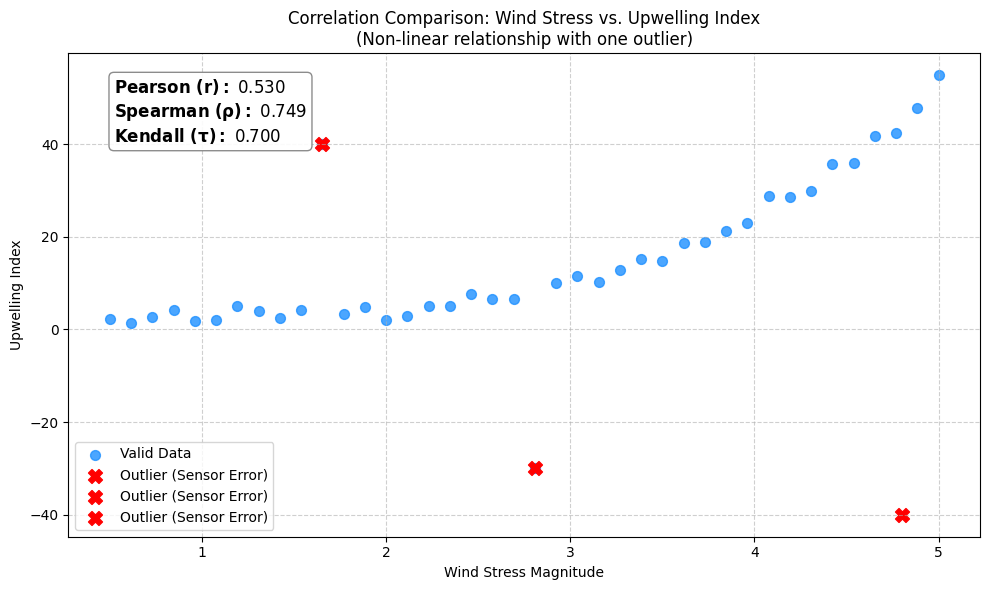

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Generate Non-Linear Data
np.random.seed(42)
# Simulate wind stress values
wind_stress = np.linspace(0.5, 5.0, 40)

# Simulate upwelling index (exponential relationship + some normal noise)
upwelling = np.exp(wind_stress * 0.8) + np.random.normal(0, 1.5, 40)

# 2. Inject an Extreme Outlier
# Let's say a sensor glitched during a high wind event, recording a massive negative value
wind_stress = np.append(wind_stress, [4.8])
upwelling = np.append(upwelling, [-40.0])
upwelling[20] = -30
upwelling[10] = 40

# 3. Compute Correlation Coefficients
pearson_r, p_pearson = stats.pearsonr(wind_stress, upwelling)
spearman_rho, p_spearman = stats.spearmanr(wind_stress, upwelling)
kendall_tau, p_kendall = stats.kendalltau(wind_stress, upwelling)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(wind_stress[:-1], upwelling[:-1], color='dodgerblue', label='Valid Data', s=50, alpha=0.8)
plt.scatter(wind_stress[-1], upwelling[-1], color='red', label='Outlier (Sensor Error)', s=100, marker='X')
plt.scatter(wind_stress[10], upwelling[10], color='red', label='Outlier (Sensor Error)', s=100, marker='X')
plt.scatter(wind_stress[20], upwelling[20], color='red', label='Outlier (Sensor Error)', s=100, marker='X')

# Add text box with the calculated coefficients
textstr = '\n'.join((
    r'$\mathbf{Pearson\ (r):}$' + f' {pearson_r:.3f}',
    r'$\mathbf{Spearman\ (\rho):}$' + f' {spearman_rho:.3f}',
    r'$\mathbf{Kendall\ (\tau):}$' + f' {kendall_tau:.3f}'
))

# Place a text box in upper left in axes coords
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.title('Correlation Comparison: Wind Stress vs. Upwelling Index\n(Non-linear relationship with one outlier)')
plt.xlabel('Wind Stress Magnitude')
plt.ylabel('Upwelling Index')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [13]:
import statsmodels.tsa.api as smt
import pandas as pd
#loading Data
data = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv",index_col="Date")
data.index = pd.to_datetime(data.index)
print(data.shape)
data.head()

(3650, 1)


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<Axes: xlabel='Date'>

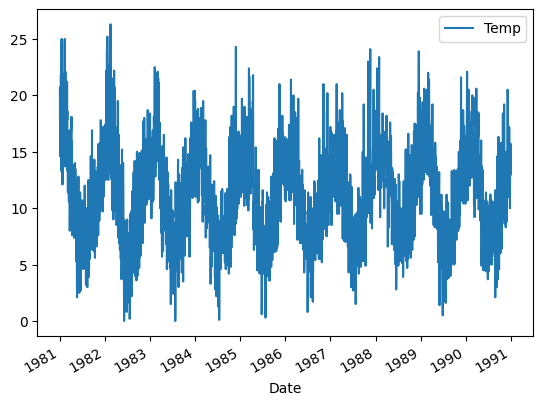

In [16]:
data.plot()

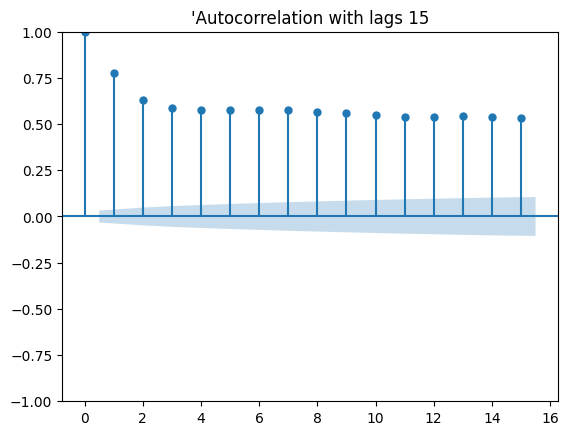

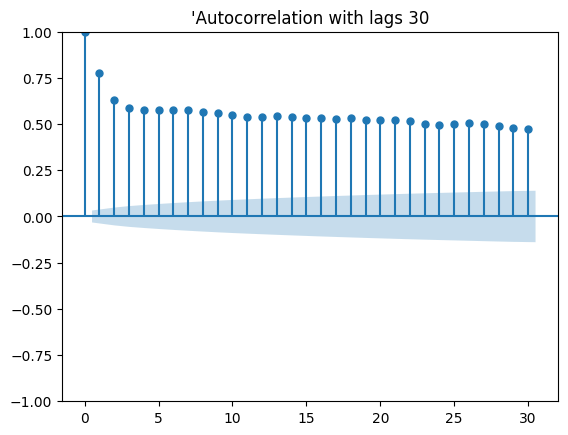

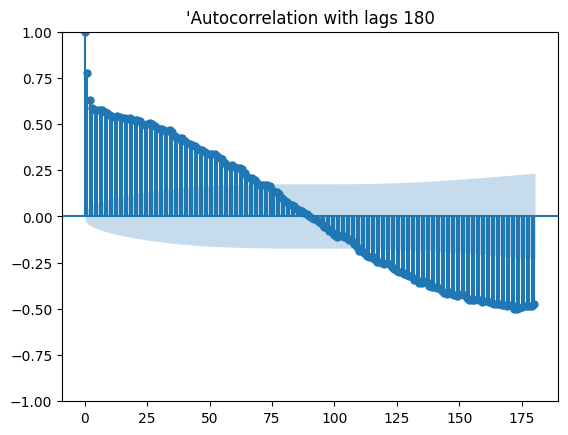

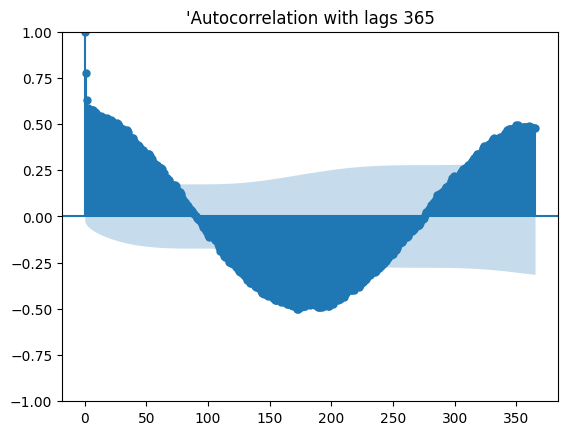

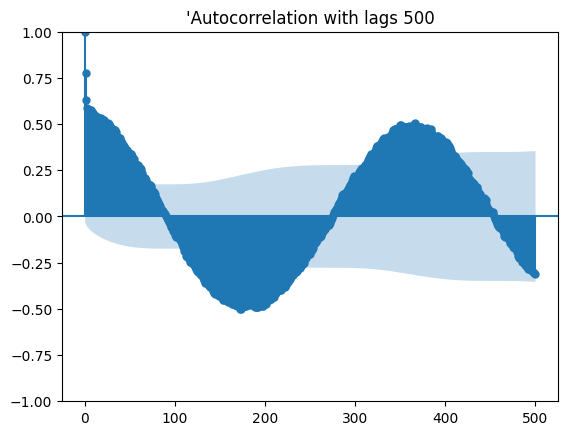

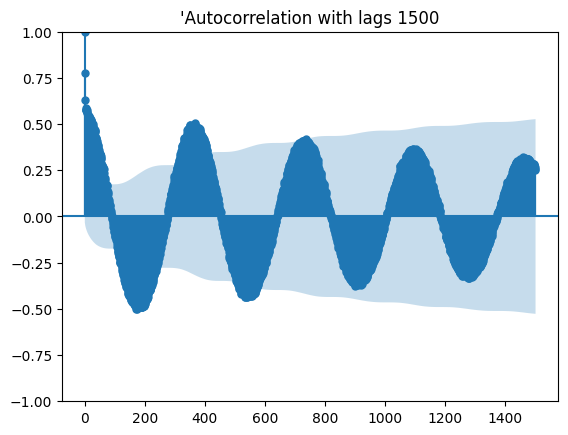

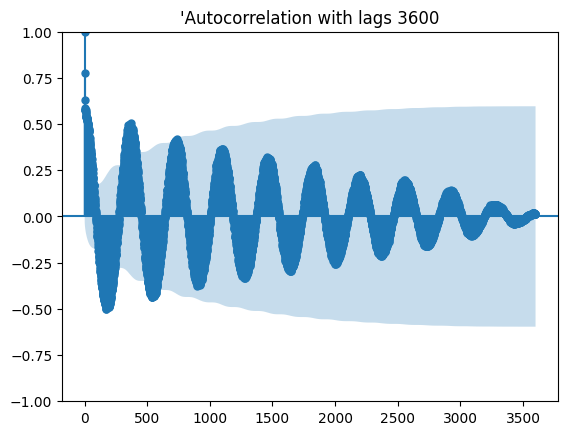

In [18]:
lags = [15,30,180,365,500,1500,3600]
for l in lags:
    titles = "'Autocorrelation with lags "+ str(l)
    smt.graphics.plot_acf(data,lags=l,alpha=0.05,title=titles)

In [19]:
data['Temp_Lag_90'] = data['Temp'].shift(90)
data.head(105)

,Temp,Temp_Lag_90
Date,,
1981-01-01,20.7,NaN
1981-01-02,17.9,NaN
1981-01-03,18.8,NaN
1981-01-04,14.6,NaN
1981-01-05,15.8,NaN
...,...,...
1981-04-11,7.6,16.2
1981-04-12,11.5,13.3
1981-04-13,13.5,16.7


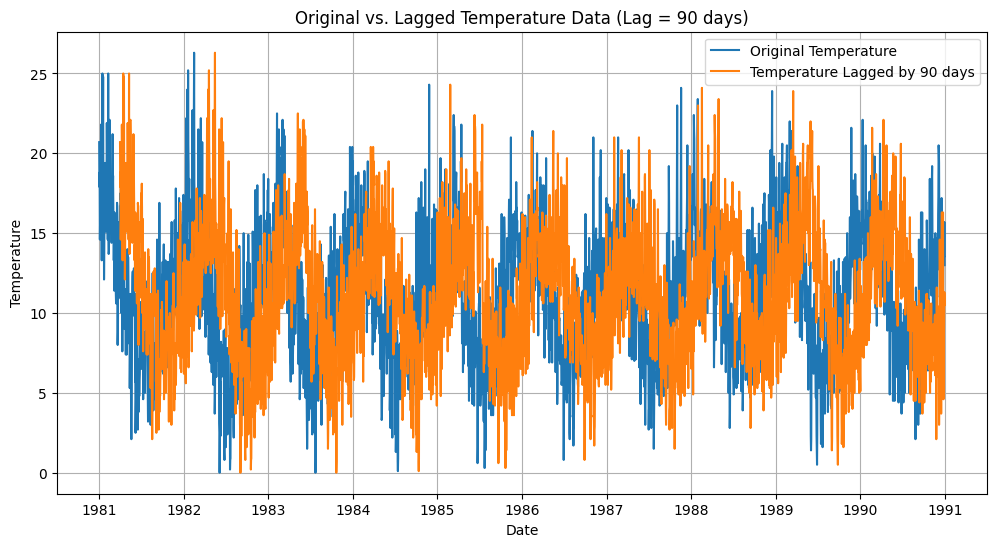

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Temp'], label='Original Temperature')
plt.plot(data.index, data['Temp_Lag_90'], label='Temperature Lagged by 90 days')
plt.title('Original vs. Lagged Temperature Data (Lag = 90 days)')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

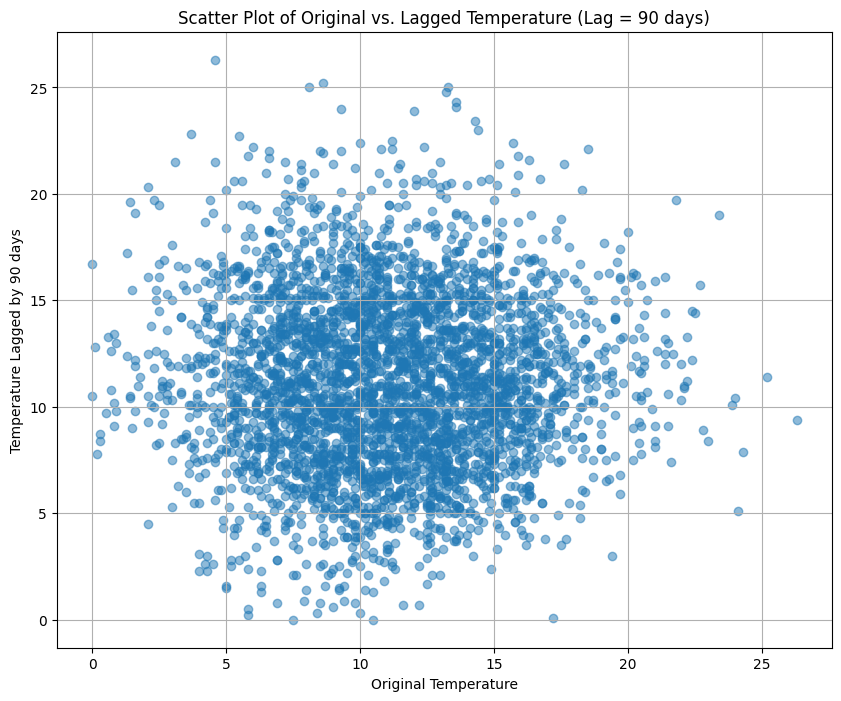

Pearson correlation coefficient: 0.0016


In [21]:
df_scatter = data.dropna(subset=['Temp', 'Temp_Lag_90'])

plt.figure(figsize=(10, 8))
plt.scatter(df_scatter['Temp'], df_scatter['Temp_Lag_90'], alpha=0.5)
plt.title('Scatter Plot of Original vs. Lagged Temperature (Lag = 90 days)')
plt.xlabel('Original Temperature')
plt.ylabel('Temperature Lagged by 90 days')
plt.grid(True)
plt.show()

correlation = pearsonr(df_scatter['Temp'], df_scatter['Temp_Lag_90'])
print(f"Pearson correlation coefficient: {correlation.statistic:.4f}")

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Scenario: We want to test if the mean upwelling index in a specific coastal region is significantly greater during Period A compared to Period B.

# 1. Generate synthetic upwelling index data for two periods
np.random.seed(42)
period_A = np.random.normal(loc=1.2, scale=0.5, size=50)
period_B = np.random.normal(loc=0.9, scale=0.6, size=45)

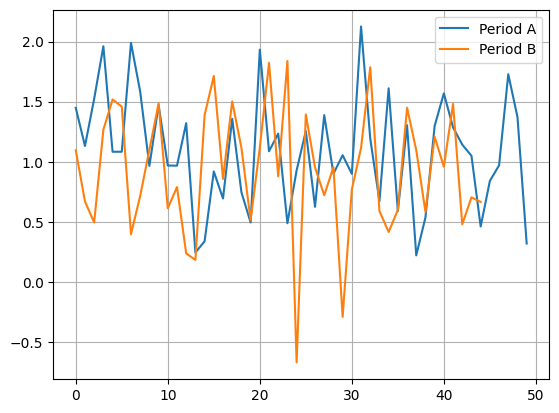

In [24]:
plt.plot(period_A)
plt.plot(period_B)
plt.grid()
plt.legend(['Period A', 'Period B'])

In [25]:
# Observed difference in means
obs_diff = np.mean(period_A) - np.mean(period_B)
print(f"Observed Difference in Means: {obs_diff:.4f}")

Observed Difference in Means: 0.1603


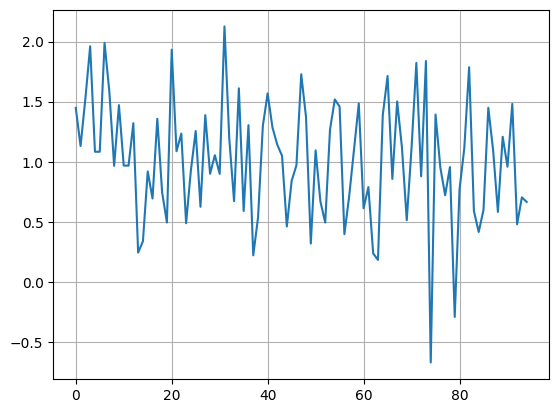

In [26]:
# 2. Bootstrap setup
B = 10000
bootstrap_diffs = np.zeros(B)

# To test the null hypothesis that means are equal, we pool the data
# and resample from the pooled data to simulate H0.
pooled_data = np.concatenate([period_A, period_B])
plt.plot(pooled_data)
plt.grid()

In [27]:
# 3. Bootstrap loop
for i in range(B):
    # Resample WITH replacement
    boot_A = np.random.choice(pooled_data, size=len(period_A), replace=True)
    boot_B = np.random.choice(pooled_data, size=len(period_B), replace=True)

    # Calculate statistic
    bootstrap_diffs[i] = np.mean(boot_A) - np.mean(boot_B)

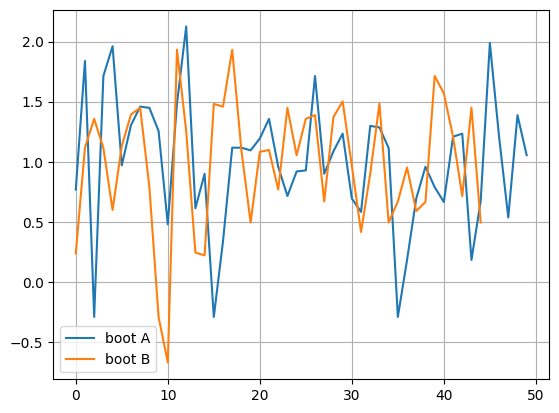

In [28]:
plt.plot(boot_A)
plt.plot(boot_B)
plt.grid()
plt.legend(['boot A', 'boot B'])

In [29]:
# 4. Calculate p-value (one-sided test: is A > B?)
p_value = np.sum(bootstrap_diffs >= obs_diff) / B
print(f"Bootstrap p-value: {p_value:.4f}")

Bootstrap p-value: 0.0584


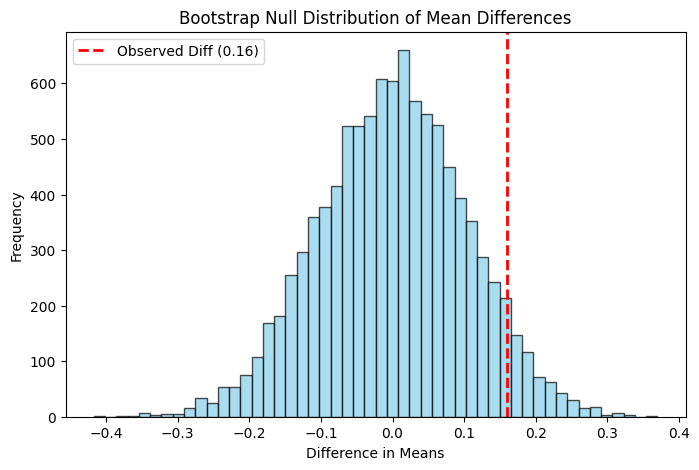

In [30]:
# 5. Visualization
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2,
            label=f'Observed Diff ({obs_diff:.2f})')
plt.title('Bootstrap Null Distribution of Mean Differences')
plt.xlabel('Difference in Means')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [31]:
# At the standard $\alpha = 0.05$ level: Since 0.0615 > 0.05,  you fail to reject the null hypothesis.
# By strict convention, you would conclude the difference is not statistically significant.
# The observed difference was large, but with a p-value of 0.0615,
# it did not reach the traditional 0.05 threshold for statistical significance.
# We have weak or marginal evidence of a difference, suggesting we might need a larger sample size to confirm
# if this physical trend is real or just natural variability.

In [32]:
# 4. Calculate the 95% Confidence Interval
# We take the 2.5th percentile and the 97.5th percentile of the distribution
ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% Confidence Interval: [-0.2003, 0.1976]


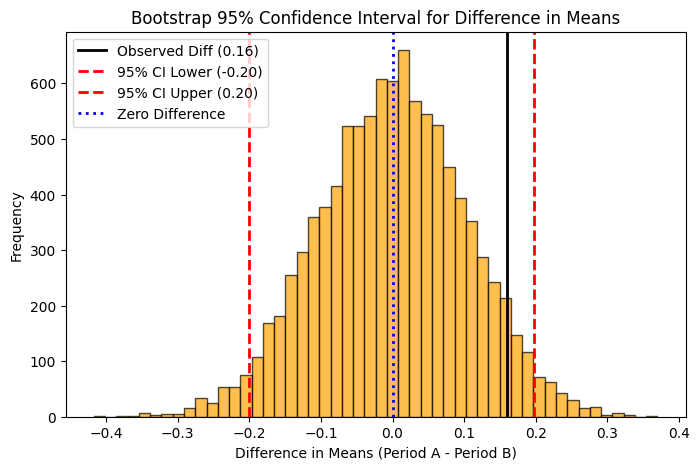

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_diffs, bins=50, color='orange', edgecolor='black', alpha=0.7)

# Plot the observed difference
plt.axvline(obs_diff, color='black', linestyle='solid', linewidth=2,
            label=f'Observed Diff ({obs_diff:.2f})')

# Plot the Confidence Interval boundaries
plt.axvline(ci_lower, color='red', linestyle='dashed', linewidth=2,
            label=f'95% CI Lower ({ci_lower:.2f})')
plt.axvline(ci_upper, color='red', linestyle='dashed', linewidth=2,
            label=f'95% CI Upper ({ci_upper:.2f})')

# Check if zero is in the interval (for two-sided significance check)
plt.axvline(0, color='blue', linestyle='dotted', linewidth=2, label='Zero Difference')

plt.title('Bootstrap 95% Confidence Interval for Difference in Means')
plt.xlabel('Difference in Means (Period A - Period B)')
plt.ylabel('Frequency')
plt.legend()

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# We observe a warming trend in a 50-year Sea Surface Temperature (SST) anomaly time series.
# Is this trend statistically significant, or could it just be an artifact of natural, autocorrelated climate noise (an AR(1) process)?

# 1. Define the observed data and trend
N_years = 50
time = np.arange(N_years)
# Synthetic observed SST with a slight trend and noise
observed_sst = 0.015 * time + np.random.normal(0, 0.4, size=N_years)

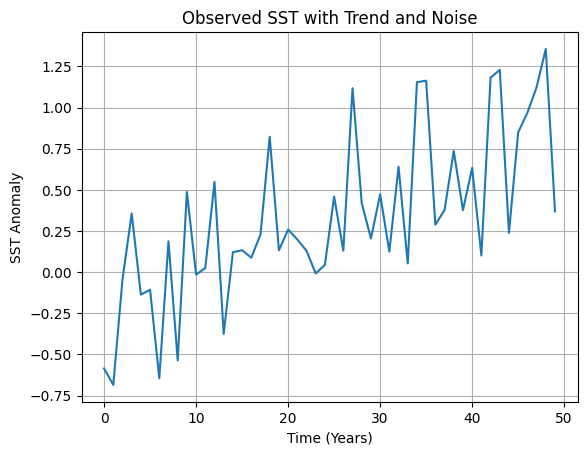

In [35]:
plt.plot(observed_sst)
plt.title('Observed SST with Trend and Noise')
plt.xlabel('Time (Years)')
plt.ylabel('SST Anomaly')
plt.grid()

In [36]:
# Fit linear trend to observed data (degree 1 polynomial)
obs_slope, obs_interception = np.polyfit(time, observed_sst, 1)
print(f"Observed Trend (Slope): {obs_slope:.4f} °C/year")

Observed Trend (Slope): 0.0238 °C/year


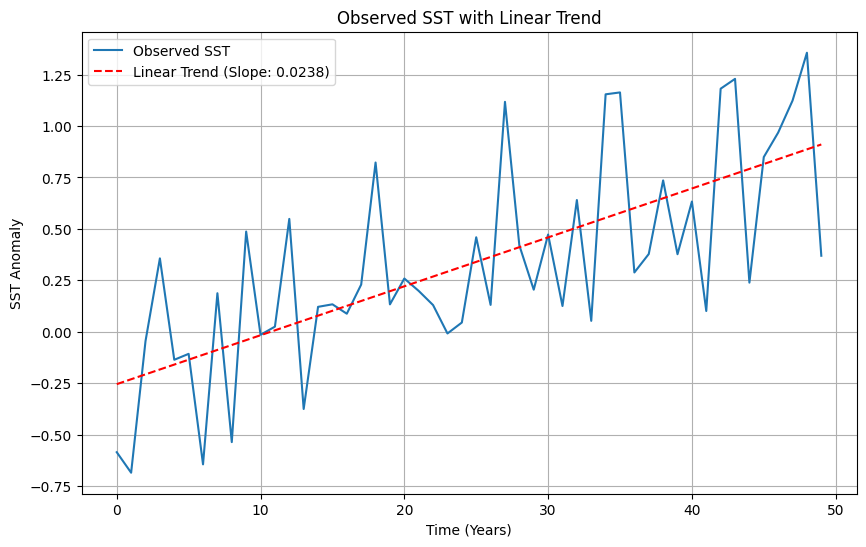

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(time, observed_sst, label='Observed SST')
plt.plot(time, obs_slope * time + obs_interception, color='red', linestyle='--', label=f'Linear Trend (Slope: {obs_slope:.4f})')
plt.title('Observed SST with Linear Trend')
plt.xlabel('Time (Years)')
plt.ylabel('SST Anomaly')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# 2. Monte Carlo setup: Define the Null Hypothesis Model
# H0: The data is just AR(1) red noise (lag-1 autocorrelation ~ 0.6) with zero underlying trend.
M = 5000
mc_slopes = np.zeros(M)
alpha = 0.6 # Autocorrelation coefficient
# A positive anomaly tends to be followed by more positive anomalies.
# This low-frequency wandering can easily mimic a deterministic trend, leading to a wider null distribution of slopes.
noise_std = np.std(observed_sst) * np.sqrt(1 - alpha**2)
print(f"Noise Standard Deviation: {noise_std:.4f}")

Noise Standard Deviation: 0.3941


np.float64(-0.014706243150559075)

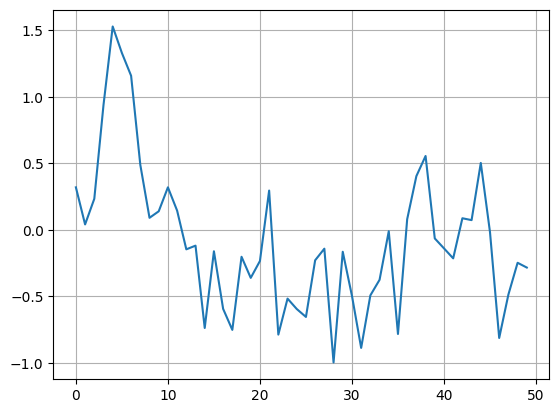

In [39]:
# 3. Monte Carlo loop
for i in range(M):
    # Generate AR(1) time series (Data Generating Process)
    simulated_sst = np.zeros(N_years)
    simulated_sst[0] = np.random.normal(0, noise_std)
    for t in range(1, N_years):
        simulated_sst[t] = alpha * simulated_sst[t-1] + np.random.normal(0, noise_std)

    # Calculate statistic (slope) for simulated data
    mc_slopes[i], _ = np.polyfit(time, simulated_sst, 1)

plt.plot(simulated_sst)
plt.grid()
mc_slopes[-1]

Monte Carlo p-value: 0.0076


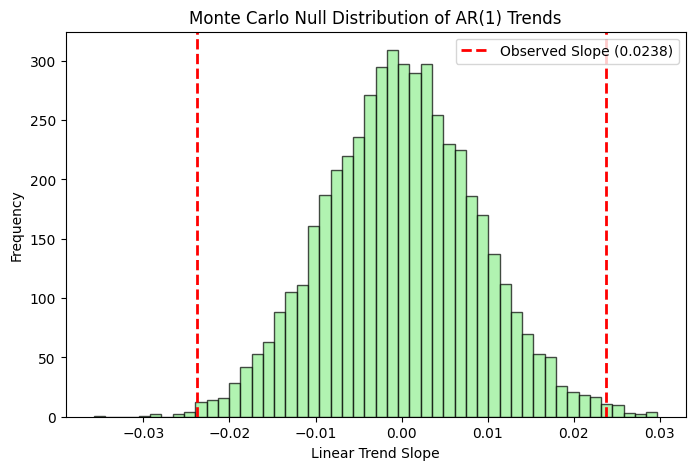

In [40]:
# 4. Calculate p-value (two-sided test)
p_value = np.sum(np.abs(mc_slopes) >= np.abs(obs_slope)) / M
print(f"Monte Carlo p-value: {p_value:.4f}")

# 5. Visualization
plt.figure(figsize=(8, 5))
plt.hist(mc_slopes, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(obs_slope, color='red', linestyle='dashed', linewidth=2,
            label=f'Observed Slope ({obs_slope:.4f})')
plt.axvline(-obs_slope, color='red', linestyle='dashed', linewidth=2)
plt.title('Monte Carlo Null Distribution of AR(1) Trends')
plt.xlabel('Linear Trend Slope')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [42]:
import xarray as xr
url = 'https://data.giss.nasa.gov/pub/gistemp/gistemp1200_GHCNv4_ERSSTv5.nc.gz'
#The dataset is small enough (23 MB) that it is sufficient to make local copy of the file.
!wget -nc {url}
ds1 = xr.open_dataset('gistemp1200_GHCNv4_ERSSTv5.nc.gz')
ds1

File ‘gistemp1200_GHCNv4_ERSSTv5.nc.gz’ already there; not retrieving.



<xarray.Dataset> Size: 114MB
Dimensions:      (time: 1753, nv: 2, lat: 90, lon: 180)
Coordinates:
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-02-09 07:49:10 by SBBX_to_nc 2.0 - ILAND=1200,...

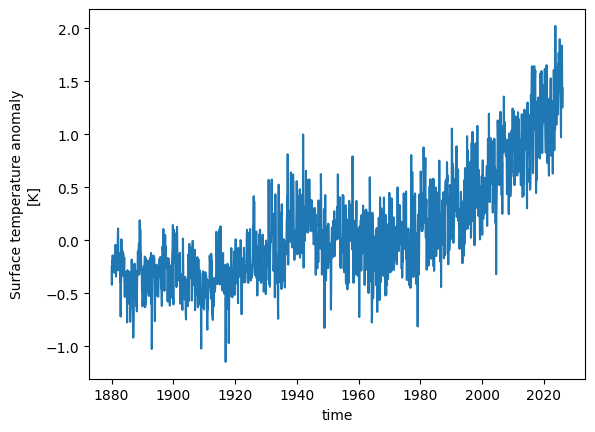

In [43]:
ds1.tempanomaly.mean(('lat','lon')).plot()

In [55]:
global_mean_temp_anomaly = ds1.tempanomaly.mean(('lat','lon'))
yearly_mean_temp_anomaly = global_mean_temp_anomaly.groupby(global_mean_temp_anomaly.time.dt.year).mean()
print(yearly_mean_temp_anomaly.head())

<xarray.DataArray 'tempanomaly' (year: 5)> Size: 40B
array([-0.23469423, -0.18562438, -0.22121686, -0.20730688, -0.38952959])
Coordinates:
  * year     (year) int64 40B 1880 1881 1882 1883 1884
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean


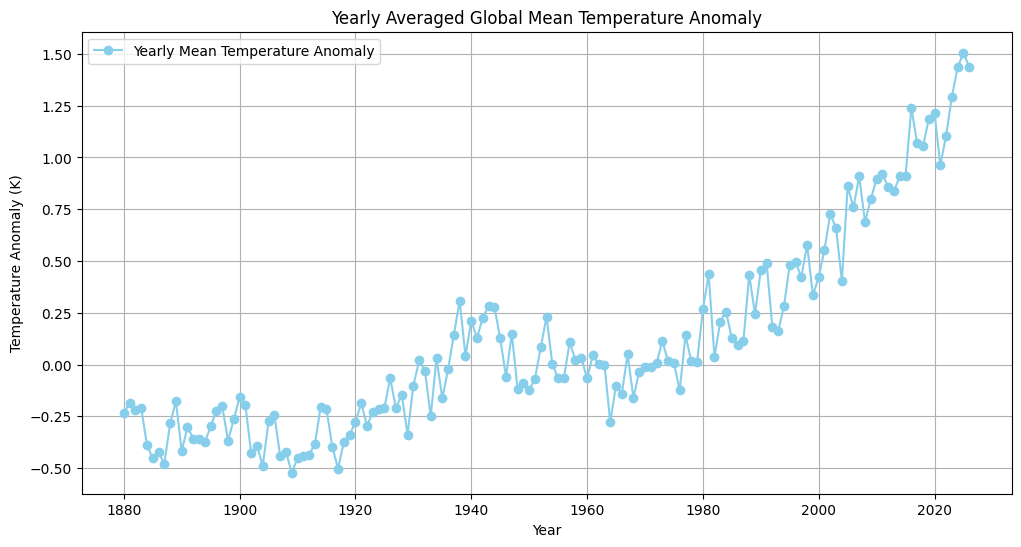

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
yearly_mean_temp_anomaly.plot(marker='o', linestyle='-', color='skyblue', label='Yearly Mean Temperature Anomaly')
plt.title('Yearly Averaged Global Mean Temperature Anomaly')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (K)')
plt.grid(True)
plt.legend()
plt.show()

In [60]:
start_year = 1880
end_year = 1980
Temp_hist = yearly_mean_temp_anomaly.sel(year=slice(start_year,end_year))
# 2. Perform a linear regression on this subset
obs_slope_1880_1980, obs_intercept_1880_1980 = np.polyfit(
    Temp_hist.year.values,
    Temp_hist.values,
    1
)

In [62]:
print(f"Observed Slope (1880-1980): {obs_slope_1880_1980:.6f}")
print(f"Observed Intercept (1880-1980): {obs_intercept_1880_1980:.6f}")

# Calculate the residuals from this fit
predicted_anomaly_1880_1980 = (obs_slope_1880_1980 * Temp_hist.year.values) + obs_intercept_1880_1980
residuals_1880_1980 = Temp_hist.values - predicted_anomaly_1880_1980

Observed Slope (1880-1980): 0.004981
Observed Intercept (1880-1980): -9.758203


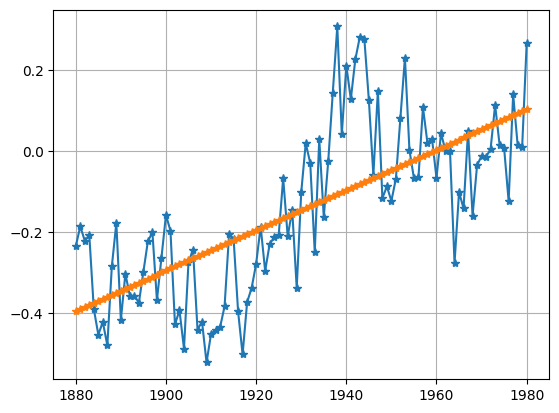

In [64]:
plt.plot(Temp_hist.year,Temp_hist,'-*')
plt.plot(Temp_hist.year,predicted_anomaly_1880_1980,'-*')
plt.grid()

In [76]:
yearly_mean_temp_anomaly

<xarray.DataArray 'tempanomaly' (year: 147)> Size: 1kB
array([-2.34694228e-01, -1.85624376e-01, -2.21216857e-01, -2.07306877e-01,
       -3.89529586e-01, -4.53326374e-01, -4.22025174e-01, -4.79645580e-01,
       -2.84371972e-01, -1.76971257e-01, -4.16939616e-01, -3.03118527e-01,
       -3.56921345e-01, -3.57686907e-01, -3.74236584e-01, -2.97554344e-01,
       -2.22007319e-01, -2.00727746e-01, -3.68243486e-01, -2.63359636e-01,
       -1.57722786e-01, -1.96324944e-01, -4.27943796e-01, -3.93102676e-01,
       -4.87931281e-01, -2.74259895e-01, -2.43030488e-01, -4.40564543e-01,
       -4.21400189e-01, -5.22055268e-01, -4.51796979e-01, -4.41326052e-01,
       -4.34986323e-01, -3.83453220e-01, -2.04774618e-01, -2.15822041e-01,
       -3.95944118e-01, -5.02290666e-01, -3.73183042e-01, -3.37890059e-01,
       -2.78373152e-01, -1.85987309e-01, -2.95741051e-01, -2.29277179e-01,
       -2.12814048e-01, -2.07878888e-01, -6.62807897e-02, -2.10545138e-01,
       -1.45377904e-01, -3.37661743e-01, -1.01530693e-01,  1.97459143e-02,
       -2.90849749e-02, -2.49334857e-01,  3.00861001e-02, -1.62594751e-01,
       -2.30525807e-02,  1.44960627e-01,  3.08533281e-01,  4.22049761e-02,
        2.11692765e-01,  1.28843933e-01,  2.27308586e-01,  2.82718122e-01,
        2.77725965e-01,  1.26596615e-01, -5.88435531e-02,  1.49426445e-01,
       -1.15870982e-01, -8.70254412e-02, -1.22702204e-01, -6.74250945e-02,
        8.31467509e-02,  2.31138825e-01,  3.15349293e-03, -6.68134093e-02,
       -6.46468401e-02,  1.08907886e-01,  1.99883655e-02,  3.15090343e-02,
       -6.61463290e-02,  4.45563495e-02,  1.50135288e-03,  1.45966813e-04,
       -2.76381165e-01, -1.01177007e-01, -1.40999049e-01,  4.96036671e-02,
       -1.59707949e-01, -3.44000496e-02, -1.15253851e-02, -1.39063308e-02,
        5.91436261e-03,  1.14347786e-01,  1.52281597e-02,  7.59473210e-03,
       -1.23564981e-01,  1.40770167e-01,  1.52167501e-02,  1.14315897e-02,
        2.66774058e-01,  4.35949296e-01,  3.68318297e-02,  2.07831398e-01,
        2.55497128e-01,  1.27257854e-01,  9.69706848e-02,  1.12905651e-01,
        4.34179574e-01,  2.43237004e-01,  4.55665499e-01,  4.91426200e-01,
        1.80901751e-01,  1.61558717e-01,  2.81050652e-01,  4.82286543e-01,
        4.94382530e-01,  4.22075003e-01,  5.78107893e-01,  3.35672826e-01,
        4.22169656e-01,  5.55017292e-01,  7.28580177e-01,  6.57582283e-01,
        4.04561013e-01,  8.60352814e-01,  7.58921921e-01,  9.08619821e-01,
        6.88182890e-01,  7.98895359e-01,  8.97368371e-01,  9.21391904e-01,
        8.57338846e-01,  8.36992562e-01,  9.09800708e-01,  9.11750019e-01,
        1.24049461e+00,  1.06799591e+00,  1.05356014e+00,  1.18371832e+00,
        1.21593285e+00,  9.62603152e-01,  1.10449731e+00,  1.29379892e+00,
        1.43535674e+00,  1.50567102e+00,  1.43634450e+00])
Coordinates:
  * year     (year) int64 1kB 1880 1881 1882 1883 1884 ... 2023 2024 2025 2026
Attributes:
    long_name:     Surface temperature anomaly
    units:         K
    cell_methods:  time: mean

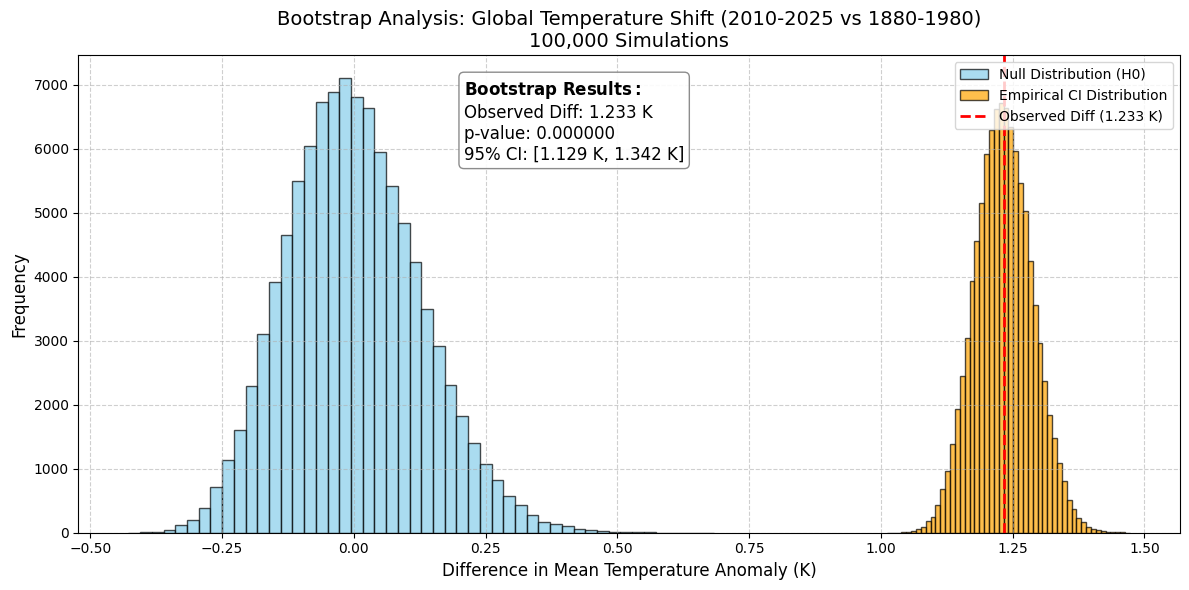

In [78]:
import numpy as np
import matplotlib.pyplot as plt

years = yearly_mean_temp_anomaly.year.values
temp_anomaly = yearly_mean_temp_anomaly.values
mask_1880_1980 = (years >= 1880) & (years <= 1980)
mask_2010_2025 = (years >= 2010) & (years <= 2025)

data_1880_1980 = temp_anomaly[mask_1880_1980]
data_2010_2025 = temp_anomaly[mask_2010_2025]

obs_diff = np.mean(data_2010_2025) - np.mean(data_1880_1980)

# 2. Bootstrap Setup
B = 100000 # 100,000 iterations
np.random.seed(42)

# --- A. Bootstrap Hypothesis Test (p-value) ---
# Pool data to simulate H0 (no difference between periods)
pooled_data = np.concatenate([data_1880_1980, data_2010_2025])
boot_null_diffs = np.zeros(B)

for i in range(B):
    boot_recent = np.random.choice(pooled_data, size=len(data_2010_2025), replace=True)
    boot_past = np.random.choice(pooled_data, size=len(data_1880_1980), replace=True)
    boot_null_diffs[i] = np.mean(boot_recent) - np.mean(boot_past)

p_value = np.sum(boot_null_diffs >= obs_diff) / B

# --- B. Bootstrap Confidence Interval ---
# Resample from their respective distributions to estimate precision
boot_ci_diffs = np.zeros(B)

for i in range(B):
    boot_recent_ci = np.random.choice(data_2010_2025, size=len(data_2010_2025), replace=True)
    boot_past_ci = np.random.choice(data_1880_1980, size=len(data_1880_1980), replace=True)
    boot_ci_diffs[i] = np.mean(boot_recent_ci) - np.mean(boot_past_ci)

ci_lower, ci_upper = np.percentile(boot_ci_diffs, [2.5, 97.5])

# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot the Null Distribution
plt.hist(boot_null_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='Null Distribution (H0)')

# Plot the Confidence Interval Distribution
plt.hist(boot_ci_diffs, bins=50, color='orange', edgecolor='black', alpha=0.7, label='Empirical CI Distribution')

# Plot the observed difference line
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, label=f'Observed Diff ({obs_diff:.3f} K)')

# Annotations and styling
plt.title('Bootstrap Analysis: Global Temperature Shift (2010-2025 vs 1880-1980)\n100,000 Simulations', fontsize=14)
plt.xlabel('Difference in Mean Temperature Anomaly (K)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Add stats text box
textstr = '\n'.join((
    r'$\mathbf{Bootstrap\ Results:}$',
    f'Observed Diff: {obs_diff:.3f} K',
    f'p-value: {p_value:.6f}',
    f'95% CI: [{ci_lower:.3f} K, {ci_upper:.3f} K]'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.gca().text(0.35, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()